In [1]:

import os, io, time, json, hashlib, pathlib, sys
import requests
import pandas as pd
import numpy as np
import importlib
from dotenv import load_dotenv
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from urllib.parse import urlparse
from datetime import datetime, timedelta
import config
import functions2 as f2
import functions1 as f1
import risk_matrix
import books

# print(holdings.IBKR_live)

importlib.reload(books)
importlib.reload(f2)
importlib.reload(config)


<module 'config' from '/Users/alexwebb/laptop_coding/risk_matrix/config.py'>

------
BOOK: IBKR_live 
-------
window_start: 2025-4-10
max_age (hrs): 0.0012 
-------
GBPCHF.FOREX - downloading fresh data
data start date b4 saving: 2019-05-16
JPYCHF.FOREX - downloading fresh data
data start date b4 saving: 2019-05-16
XMWX.LSE - downloading fresh data
XMWX.LSE - cleaned 2 flat-bar spike(s) on download
data start date b4 saving: 2024-08-27
               Open     High      Low    Close  Adjusted_close  Volume
Date                                                                  
2025-10-14  29.0300  29.4500  28.5400  29.2650         29.2650   59424
2025-10-15  29.4350  29.8200  29.3950  29.3950         29.3950   78202
2025-10-16  29.5500  29.5500  29.3050  29.4650         29.4650  100287
2025-10-17  29.4000  29.5800  29.0050  29.3125         29.3125   67588
2025-10-20  29.5300  29.9350  29.2100  29.6700         29.6700  191349
2025-10-21  29.6300  29.6500  29.4975  29.5650         29.5650   61151
2025-10-22  29.6600  29.7150  29.5000  29.5425         29.5425   53699

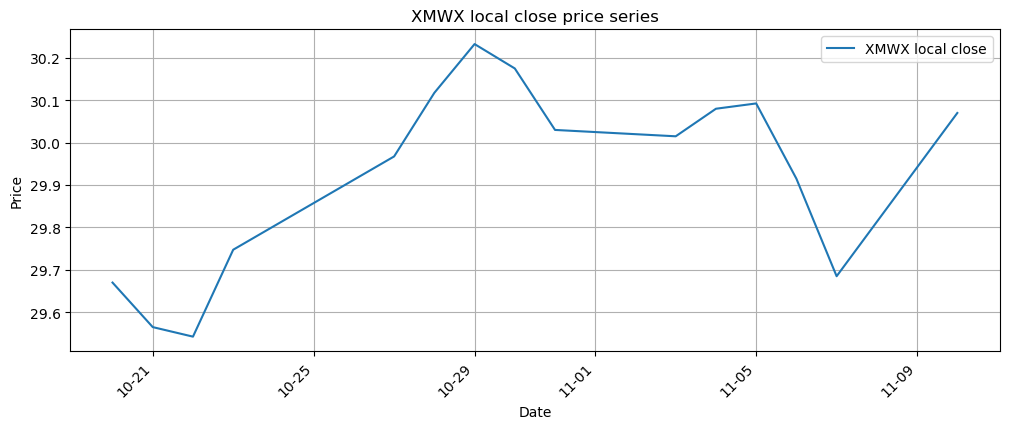

EMIM.LSE - downloading fresh data
data start date b4 saving: 2019-05-16
              Open    High       Low   Close  Adjusted_close   Volume
Date                                                                 
2025-10-14  3222.0  3238.0  3206.794  3238.0          3238.0   277884
2025-10-15  3273.0  3287.0  3263.000  3271.0          3271.0   185694
2025-10-16  3290.0  3301.0  3279.000  3294.5          3294.5   114004
2025-10-17  3240.0  3281.0  3221.000  3269.0          3269.0   341449
2025-10-20  3295.0  3332.0  3289.000  3322.0          3322.0   145486
2025-10-21  3320.0  3326.0  3299.000  3304.0          3304.0   130060
2025-10-22  3326.0  3330.0  3302.000  3302.0          3302.0   181211
2025-10-23  3317.0  3336.0  3305.000  3336.0          3336.0   101013
2025-10-24  3351.0  3369.0  3344.480  3364.0          3364.0   917011
2025-10-27  3384.0  3391.0  3376.000  3387.0          3387.0   850700
2025-10-28  3359.0  3396.0  3355.000  3396.0          3396.0   122949
2025-10-29  3426.0

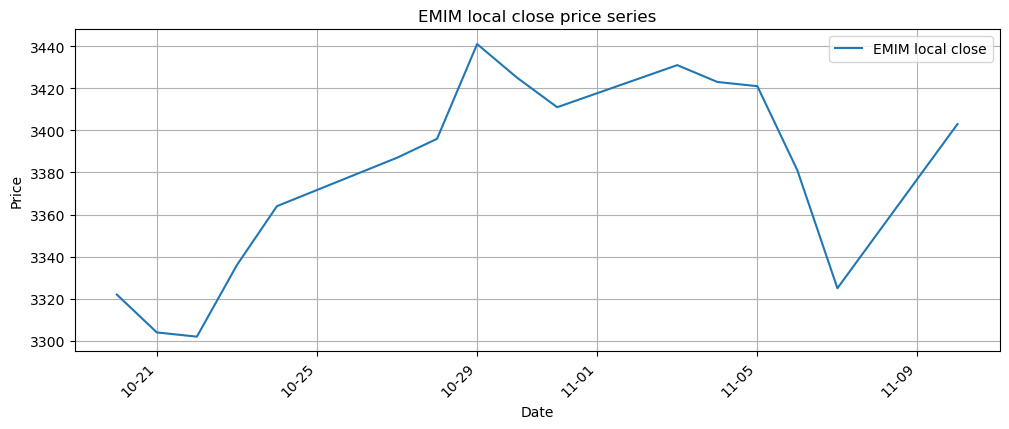

VUAG.LSE - downloading fresh data
data start date b4 saving: 2019-05-16
              Open    High    Low    Close  Adjusted_close  Volume
Date                                                              
2025-10-14   95.33   95.65  94.58   95.520          95.520  414734
2025-10-15   95.76   96.58  95.70   95.750          95.750  382998
2025-10-16   95.65   96.03  95.34   95.490          95.490  294947
2025-10-17   93.74   95.26  93.20   94.630          94.630  674074
2025-10-20   95.60   97.00  95.34   96.135          96.135  483748
2025-10-21   96.35   98.00  96.28   96.610          96.610  245501
2025-10-22   97.03   97.20  96.09   96.110          96.110  320142
2025-10-23   96.43   96.84  96.06   96.800          96.800  311425
2025-10-24   97.26   98.12  97.01   98.055          98.055  389364
2025-10-27   98.65   98.80  98.31   98.630          98.630  549900
2025-10-28   98.80   99.76  98.75   99.420          99.420  419306
2025-10-29  100.22  100.50  99.88  100.100         100.10

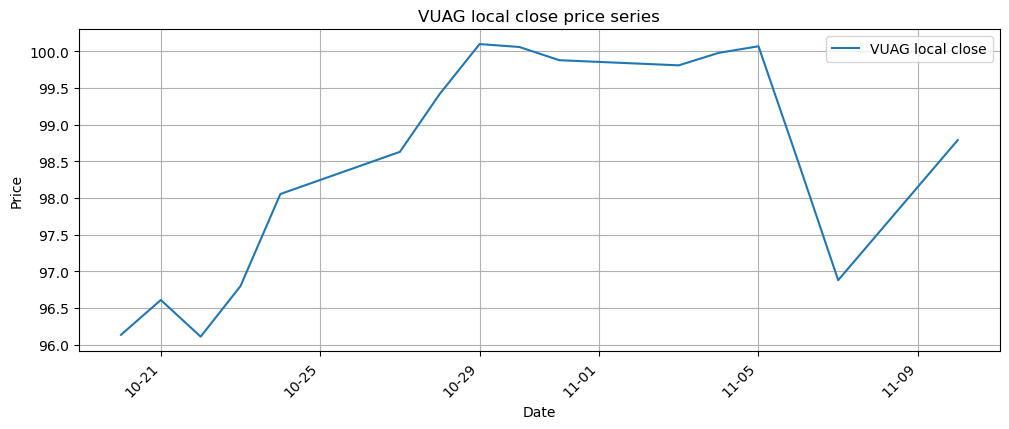

ISJP.SW - downloading fresh data
data start date b4 saving: 2019-05-16
              Open    High     Low   Close  Adjusted_close  Volume
Date                                                              
2025-10-13  7696.0  7696.0  7534.0  7581.0          7581.0    5512
2025-10-14  7468.0  7539.0  7467.0  7539.0          7539.0    4681
2025-10-15  7665.0  7665.0  7633.0  7648.0          7648.0    2827
2025-10-16  7648.0  7648.0  7648.0  7648.0          7648.0       0
2025-10-17  7520.0  7646.0  7520.0  7613.0          7613.0    4269
2025-10-20  7691.0  7713.0  7691.0  7711.0          7711.0    2943
2025-10-21  7702.0  7703.0  7694.0  7703.0          7703.0    3444
2025-10-22  7735.0  7742.0  7724.0  7732.0          7732.0    1862
2025-10-23  7779.0  7803.0  7779.0  7803.0          7803.0    4401
2025-10-24  7801.0  7860.0  7801.0  7860.0          7860.0    3837
2025-10-27  7885.0  7885.0  7885.0  7885.0          7885.0       2
2025-10-28  7755.0  7762.0  7752.0  7762.0          7762.0

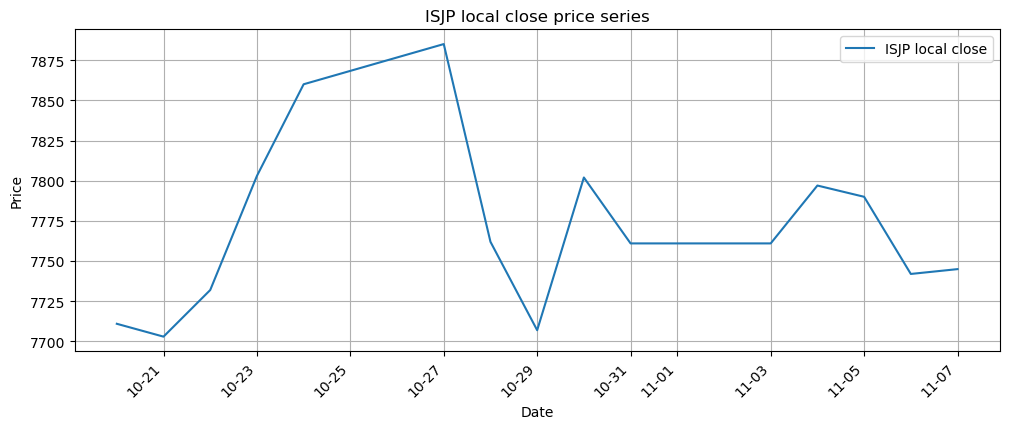

IEMS.LSE - downloading fresh data
data start date b4 saving: 2019-05-16
              Open      High      Low    Close  Adjusted_close  Volume
Date                                                                  
2025-10-14   98.61   99.2100   98.230   98.945          98.945    3878
2025-10-15  100.54  100.9900  100.200  100.655         100.655    2072
2025-10-16  101.37  101.8100  101.150  101.660         101.660    2603
2025-10-17  102.99  102.9900   99.430  100.800         100.800     617
2025-10-20  101.14  102.0900  100.560  101.775         101.775    1125
2025-10-21  103.00  103.0000  100.900  101.360         101.360    3800
2025-10-22  101.67  103.0000  101.630  101.630         101.630    7544
2025-10-23  101.53  102.3100  101.310  102.310         102.310     190
2025-10-24  101.27  103.0000  101.270  102.675         102.675    3415
2025-10-27  103.00  103.3000  102.775  102.775         102.775     774
2025-10-28  102.90  103.5800  102.790  103.385         103.385    1399
2025-

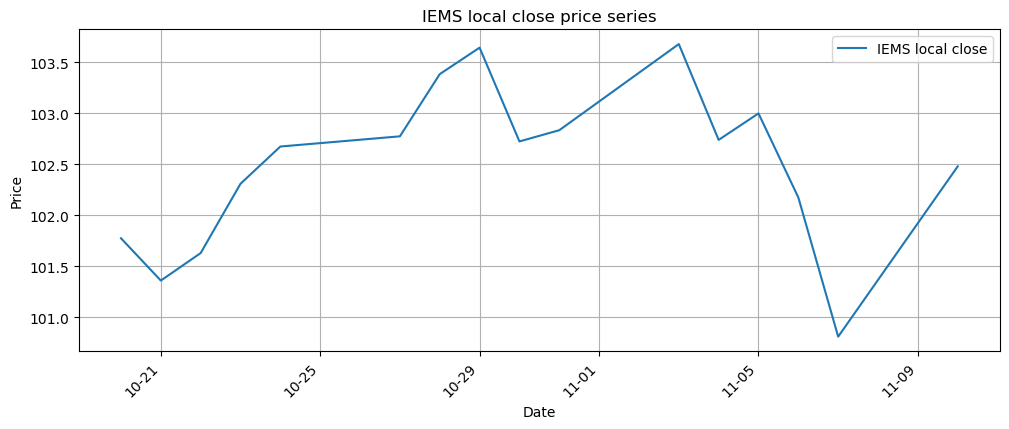

NOVN.SW - downloading fresh data
data start date b4 saving: 2019-05-16
              Open    High     Low   Close  Adjusted_close   Volume
Date                                                               
2025-10-14  103.78  104.68  103.68  104.04          104.04  2278420
2025-10-15  103.40  104.04  102.38  104.04          104.04  2686895
2025-10-16  102.92  104.46  102.92  104.34          104.34  2332545
2025-10-17  103.74  104.22  102.60  104.22          104.22  2970487
2025-10-20  103.62  104.74  103.42  104.14          104.14  2559750
2025-10-21  104.62  104.86  104.10  104.56          104.56  2187946
2025-10-22  104.24  105.36  104.14  104.86          104.86  2551662
2025-10-23  104.10  104.96  103.96  104.52          104.52  1975178
2025-10-24  105.00  105.00  103.80  104.08          104.08  2546676
2025-10-27  103.02  103.34  101.24  103.16          103.16  4028376
2025-10-28   99.71  100.50   98.16   98.87           98.87  5520831
2025-10-29   97.80   98.54   97.05   98.50   

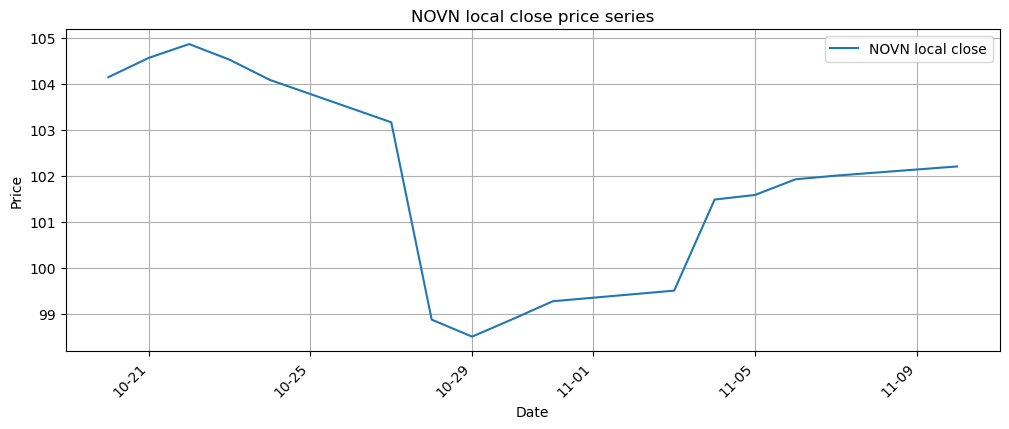

chf equiv latest 102.2
chf equiv latest 1.0604
chf equiv latest 0.0052
After alignment only 121 rows remain (expected 214 days 00:00:00). Data source may not have full history.
asset close chf EMIM 33.25
LOOKBACK DAYS/REGIME: 2025-04-10 00:00:00 to 2025-11-10 00:00:00  (214 days)
Total portfolio value (CHF): 12046.69
XMWX: value CHF10192.13,  last 29.68 *fx* 324
EMIM: value CHF2184.57,  last 33.25 *fx* 62
VUAG: value CHF2361.27,  last 96.88 *fx* 23
ISJP: value CHF820.97,  last 7745.00 *fx* 20
IEMS: value CHF427.31,  last 100.81 *fx* 4
NOVN: value CHF1938.00,  last 102.00 *fx* 19
CASH_GBP: value CHF-1589.55,  last 1.06 *fx* 0.0
CASH_JPY: value CHF-4288.01,  last 0.01 *fx* 0.0
++++++ portfolio_risk()
Portfolio σ (an_adjnualized, CHF): 17.70%
 CORE EQUITY BAND = 15 - 30%, DIVERSIFIERS = 5 - 12%, TACTICALS <= 10%,
equity core max 30%, diversifiers max 12%, tacticals max 10%, total max 15%
          Weight  Vol_1Y_CHF    MRC  PRC_%
XMWX       0.846       0.127  0.119   56.7
VUAG       0.196

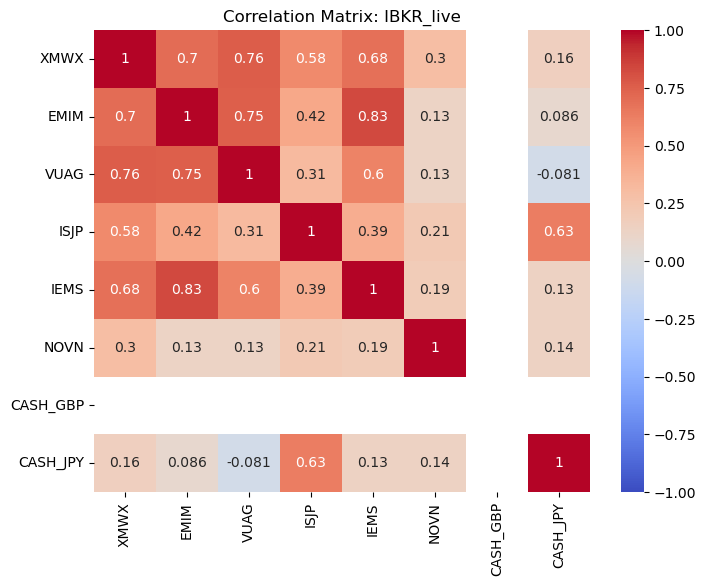

In [6]:

PORTFOLIO = 'IBKR_live' 
            # 'IBKR_live_adj'  
            # 'IBKR_sim' 
            # 'exp' 
holdings=getattr(books, PORTFOLIO)  # verify it exists

DEBUG = False
window_start = '2025-4-10'
window_end = None
print('------\nBOOK:', PORTFOLIO, '\n-------')
max_age = config.params.get('max_age', 0)
print('window_start:', window_start)
print('max_age (hrs):', max_age, '\n-------')



rets_df, prices_df, w = risk_matrix.build_returns_weights(holdings, params=config.params, no_fx=False, usd_shift=False, window_start=window_start, window_end=window_end)

risk = risk_matrix.portfolio_risk(rets_df, w)

# print( rets_df.tail(3) )
print("Portfolio σ (an_adjnualized, CHF): {:.2%}".format(risk["port_vol"]))
print(" CORE EQUITY BAND = 15 - 30%, DIVERSIFIERS = 5 - 12%, TACTICALS <= 10%,")
print('equity core max 30%, diversifiers max 12%, tacticals max 10%, total max 15%')
print(risk["summary"].round({"Weight":3,"Vol_1Y_CHF":3,"MRC":3,"PRC_%":1, }))
print(f'CORRELATION:')
print(f'{risk["corr"].round(2)}')
print(f'COVARIANCE:')
print(f'{risk["cov_annual"]}')

corr_matrix = risk["corr"]

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title(f"Correlation Matrix: {PORTFOLIO}")
plt.show()

In [7]:
def eod_search(quey: str, token: str):
    import requests, pandas as pd
    url = f"https://eodhd.com/api/search/{quey}?api_token={token}&fmt=json"
    r = requests.get(url, timeout=30); r.raise_for_status()
    hits = r.json()
    # Return a small table to pick from
    return pd.DataFrame([{
        "code": h.get("Code"),
        "exchange": h.get("Exchange"),
        "name": h.get("Name"),
        "currency": h.get("Currency"),
        "type": h.get("Type"),
        "startdate": h.get("StartDate"),
        # earliet date

    } for h in hits])

# Usage:
df = eod_search("litg", config.EOD_API)
# pick the line with the longest available history (often XETRA/LSE/SIX)
print(df)

   code exchange                                               name currency  \
0  LITG      LSE  Global X Lithium & Battery Tech UCITS ETF USD ...      GBP   

  type startdate  
0  ETF      None  


## GET THE EARLIEST DATE ##

In [8]:
START = '2020-01-02'
ticker = 'XMWX.LSE'


# Fetch EODHD daily FX and build a Series
fx_df = f1.fetch_csv_robust(ticker, params=config.params)
print(fx_df.head(1))

XMWX.LSE - downloading fresh data
XMWX.LSE - cleaned 2 flat-bar spike(s) on download
data start date b4 saving: 2024-08-27
               Open     High      Low    Close  Adjusted_close  Volume
Date                                                                  
2024-08-27  33.1258  33.1258  33.1258  33.1258         33.1258       0


## Equity correlation drift check
We’ll:
- compute a 60-day rolling average pairwise correlation across the equity ETFs in your `rets_df`.
- show the 1-year view you’re using now (limited by `XMWX`).
- also compute a 3-year view excluding `XMWX` (if data exist), to see whether the increase is structural or just recent.

In [9]:
# 1) Current 1-year view (already in rets_df)
# Pick equity ETFs present in rets_df
all_cols = list(rets_df.columns)
EQUITY_LIKE = [c for c in ["EMIM","VUAG","WSML","XMWX","IBM"] if c in all_cols]

if len(EQUITY_LIKE) >= 2:
    rets_eq_1y = rets_df[EQUITY_LIKE]
    # 60D rolling average of pairwise correlation (off-diagonal mean)
    def offdiag_mean(corr_m):
        if corr_m.shape[0] < 2:
            return np.nan
        n = corr_m.shape[0]
        return (corr_m.values.sum() - n) / (n*(n-1))

    roll_avg_corr_1y = (
        rets_eq_1y.rolling(60).corr().groupby(level=0).apply(lambda c: offdiag_mean(c))
    )

    print("1Y rolling(60) avg pairwise equity corr (tail):")
    print(roll_avg_corr_1y.dropna().tail(10))
else:
    print("Not enough equity-like tickers to compute 1Y pairwise correlation.")

# 2) Longer 3Y view excluding XMWX (if data available): re-fetch or extend window is out of scope here,
# but we can approximate by checking if older data exist in prices_df; if not, we demonstrate exclusion-only.
try:
    # If you want to explicitly exclude XMWX to avoid its shorter history limiting the window
    EQUITY_NO_XMWX = [c for c in EQUITY_LIKE if c != "XMWX"]
    if len(EQUITY_NO_XMWX) >= 2:
        # Use available rets_df (1Y). For a true 3Y view, rerun 
        rets_eq_ex = rets_df[EQUITY_NO_XMWX]
        roll_avg_corr_ex = (
            rets_eq_ex.rolling(60).corr().groupby(level=0).apply(lambda c: offdiag_mean(c))
        )
        print("Ex-XMWX rolling(60) avg pairwise equity corr (tail):")
        print(roll_avg_corr_ex.dropna().tail(756))
    else:
        print("Not enough non-XMWX equity-like tickers to compute ex-XMWX correlation.")
except Exception as e:
    print("Correlation analysis note:", e)


1Y rolling(60) avg pairwise equity corr (tail):
Date
2025-10-27    0.673605
2025-10-28    0.684952
2025-10-29    0.693848
2025-10-30    0.699943
2025-10-31    0.703366
2025-11-03    0.709101
2025-11-04    0.712632
2025-11-05    0.715051
2025-11-06    0.715989
2025-11-07    0.736810
dtype: float64
Ex-XMWX rolling(60) avg pairwise equity corr (tail):
Date
2025-08-14    0.770859
2025-08-15    0.784273
2025-08-18    0.771190
2025-08-19    0.769271
2025-08-20    0.766913
                ...   
2025-11-03    0.681721
2025-11-04    0.684518
2025-11-05    0.684621
2025-11-06    0.691899
2025-11-07    0.728224
Length: 61, dtype: float64
